In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/prachiii33/garbageds/Garbage/Garbage_bin_00069.jpg
/kaggle/input/datasets/prachiii33/garbageds/Garbage/Garbage_bin_000139.jpg
/kaggle/input/datasets/prachiii33/garbageds/Garbage/Garbage_bin_00090.jpg
/kaggle/input/datasets/prachiii33/garbageds/Garbage/Garbage_bin_000135.xml
/kaggle/input/datasets/prachiii33/garbageds/Garbage/Garbage_bin_00059.jpg
/kaggle/input/datasets/prachiii33/garbageds/Garbage/Garbage_bin_00034.xml
/kaggle/input/datasets/prachiii33/garbageds/Garbage/Garbage_bin_00023.jpg
/kaggle/input/datasets/prachiii33/garbageds/Garbage/Garbage_bin_00079.xml
/kaggle/input/datasets/prachiii33/garbageds/Garbage/Garbage_bin_000113.jpg
/kaggle/input/datasets/prachiii33/garbageds/Garbage/Garbage_bin_00067.jpg
/kaggle/input/datasets/prachiii33/garbageds/Garbage/Garbage_bin_00016.xml
/kaggle/input/datasets/prachiii33/garbageds/Garbage/Garbage_bin_000138.xml
/kaggle/input/datasets/prachiii33/garbageds/Garbage/Garbage_bin_00072.jpg
/kaggle/input/datasets/prachiii33/

In [2]:
!pip install -q ultralytics gradio pandas pyyaml scikit-learn opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.8 MB/s eta 0:00:00a 0:00:01


In [3]:
import os
import shutil
import random
import subprocess
import uuid
import csv
import json

from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import yaml
import torch

from sklearn.model_selection import train_test_split
from ultralytics import YOLO

print("All libraries imported successfully.")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All libraries imported successfully.


In [4]:
EXPECTED_CLASSES = [
    "Broken trash can",
    "Healthy trash can",
    "Trash can closed",
    "Trash can open",
    "Trash over flow"
]


def find_dataset_root():

    search_roots = [
        Path("/kaggle/input"),
        Path("/kaggle/working")
    ]

    candidates = []

    for root in search_roots:

        if not root.exists():
            continue

        for yaml_file in root.rglob("data.yaml"):

            try:

                with open(
                    yaml_file,
                    "r",
                    encoding="utf-8"
                ) as f:
                    data = yaml.safe_load(f)

                names = data.get("names", [])

                if isinstance(names, dict):
                    names = list(names.values())

                names = [str(x) for x in names]

                if names == EXPECTED_CLASSES:

                    candidates.append(
                        yaml_file.parent
                    )

            except Exception:
                continue

    if not candidates:

        raise FileNotFoundError(
            "Could not automatically find your dataset.\n"
            "Please set DATASET_SOURCE manually."
        )

    # Prefer Kaggle input over working directory
    candidates.sort(
        key=lambda p:
        0 if str(p).startswith("/kaggle/input")
        else 1
    )

    return candidates[0]


DATASET_SOURCE = find_dataset_root()

print("Dataset found at:")
print(DATASET_SOURCE)

Dataset found at:
/kaggle/input/datasets/prachiii33/garbagebin


In [5]:
DATA_YAML_SOURCE = DATASET_SOURCE / "data.yaml"

with open(
    DATA_YAML_SOURCE,
    "r",
    encoding="utf-8"
) as f:

    original_yaml = yaml.safe_load(f)

print("Classes found in dataset:")

names = original_yaml["names"]

if isinstance(names, dict):
    names = list(names.values())

for i, name in enumerate(names):
    print(f"{i}: {name}")

Classes found in dataset:
0: Broken trash can
1: Healthy trash can
2: Trash can closed
3: Trash can open
4: Trash over flow


In [6]:
PROJECT_DIR = Path(
    "/kaggle/working/trash_can_overflow_project"
)

SPLIT_DATASET = (
    PROJECT_DIR /
    "dataset"
)

TRAIN_IMG = (
    SPLIT_DATASET /
    "train" /
    "images"
)

TRAIN_LBL = (
    SPLIT_DATASET /
    "train" /
    "labels"
)

VAL_IMG = (
    SPLIT_DATASET /
    "valid" /
    "images"
)

VAL_LBL = (
    SPLIT_DATASET /
    "valid" /
    "labels"
)

TEST_IMG = (
    SPLIT_DATASET /
    "test" /
    "images"
)

TEST_LBL = (
    SPLIT_DATASET /
    "test" /
    "labels"
)


for folder in [
    TRAIN_IMG,
    TRAIN_LBL,
    VAL_IMG,
    VAL_LBL,
    TEST_IMG,
    TEST_LBL
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("Clean dataset structure created.")

Clean dataset structure created.


In [7]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


def collect_pairs(dataset_root):

    pairs = []

    for image_file in dataset_root.rglob("*"):

        if (
            not image_file.is_file()
            or
            image_file.suffix.lower()
            not in IMAGE_EXTENSIONS
        ):
            continue

        label_file = (
            image_file.parent.parent /
            "labels" /
            f"{image_file.stem}.txt"
        )

        if not label_file.exists():

            # Search more broadly
            possible = list(
                dataset_root.rglob(
                    f"{image_file.stem}.txt"
                )
            )

            if possible:
                label_file = possible[0]

        if label_file.exists():

            pairs.append(
                (
                    image_file,
                    label_file
                )
            )

    return pairs


pairs = collect_pairs(
    DATASET_SOURCE
)

print(
    f"Image-label pairs found: {len(pairs)}"
)

if len(pairs) < 100:

    raise RuntimeError(
        "Too few image-label pairs were found. "
        "Check the dataset path and structure."
    )

Image-label pairs found: 1974


In [8]:
class_counter = Counter()

for _, label_file in pairs:

    with open(
        label_file,
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:

            parts = line.strip().split()

            if not parts:
                continue

            class_id = int(parts[0])

            class_counter[class_id] += 1


print("Object counts:")

for class_id in range(5):

    print(
        f"{class_id} - "
        f"{EXPECTED_CLASSES[class_id]}: "
        f"{class_counter[class_id]}"
    )

Object counts:
0 - Broken trash can: 351
1 - Healthy trash can: 602
2 - Trash can closed: 560
3 - Trash can open: 532
4 - Trash over flow: 1593


In [9]:
def get_primary_class(label_file):

    counts = Counter()

    with open(
        label_file,
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:

            parts = line.strip().split()

            if not parts:
                continue

            class_id = int(parts[0])

            counts[class_id] += 1

    if not counts:
        return -1

    return counts.most_common(1)[0][0]


primary_classes = [
    get_primary_class(label)
    for _, label in pairs
]

valid_pairs = []

valid_primary = []

for pair, cls in zip(
    pairs,
    primary_classes
):

    if cls >= 0:
        valid_pairs.append(pair)
        valid_primary.append(cls)


pairs = valid_pairs
primary_classes = valid_primary


try:

    train_pairs, temp_pairs = train_test_split(
        pairs,
        test_size=0.20,
        random_state=42,
        stratify=primary_classes
    )

    temp_classes = [
        get_primary_class(label)
        for _, label in temp_pairs
    ]

    val_pairs, test_pairs = train_test_split(
        temp_pairs,
        test_size=0.50,
        random_state=42,
        stratify=temp_classes
    )

except ValueError:

    print(
        "Stratified split unavailable. "
        "Using random split instead."
    )

    train_pairs, temp_pairs = train_test_split(
        pairs,
        test_size=0.20,
        random_state=42
    )

    val_pairs, test_pairs = train_test_split(
        temp_pairs,
        test_size=0.50,
        random_state=42
    )


print(
    "TRAIN:",
    len(train_pairs)
)

print(
    "VALID:",
    len(val_pairs)
)

print(
    "TEST:",
    len(test_pairs)
)

TRAIN: 1409
VALID: 176
TEST: 177


In [10]:
def copy_pairs(
    pairs,
    image_destination,
    label_destination,
    split_name
):

    for index, (
        image_file,
        label_file
    ) in enumerate(pairs):

        new_stem = (
            f"{split_name}_{index:05d}"
        )

        new_image = (
            image_destination /
            f"{new_stem}{image_file.suffix.lower()}"
        )

        new_label = (
            label_destination /
            f"{new_stem}.txt"
        )

        shutil.copy2(
            image_file,
            new_image
        )

        shutil.copy2(
            label_file,
            new_label
        )


copy_pairs(
    train_pairs,
    TRAIN_IMG,
    TRAIN_LBL,
    "train"
)

copy_pairs(
    val_pairs,
    VAL_IMG,
    VAL_LBL,
    "valid"
)

copy_pairs(
    test_pairs,
    TEST_IMG,
    TEST_LBL,
    "test"
)

print("Dataset split completed.")

Dataset split completed.


In [11]:
def count_files(
    folder,
    extensions
):

    return len([
        f
        for f in folder.iterdir()
        if f.is_file()
        and f.suffix.lower()
        in extensions
    ])


for split in [
    "train",
    "valid",
    "test"
]:

    img_dir = (
        SPLIT_DATASET /
        split /
        "images"
    )

    lbl_dir = (
        SPLIT_DATASET /
        split /
        "labels"
    )

    images = count_files(
        img_dir,
        IMAGE_EXTENSIONS
    )

    labels = count_files(
        lbl_dir,
        {".txt"}
    )

    print(
        f"\n{split.upper()}"
    )

    print(
        "Images :",
        images
    )

    print(
        "Labels :",
        labels
    )

    if images != labels:

        raise RuntimeError(
            f"{split}: image/label mismatch!"
        )


TRAIN
Images : 1409
Labels : 1409

VALID
Images : 176
Labels : 176

TEST
Images : 177
Labels : 177


In [12]:
NEW_DATA_YAML = (
    SPLIT_DATASET /
    "data.yaml"
)

dataset_config = {

    "path": str(SPLIT_DATASET),

    "train": "train/images",

    "val": "valid/images",

    "test": "test/images",

    "names": EXPECTED_CLASSES

}


with open(
    NEW_DATA_YAML,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        dataset_config,
        f,
        sort_keys=False
    )


print(
    NEW_DATA_YAML.read_text()
)

path: /kaggle/working/trash_can_overflow_project/dataset
train: train/images
val: valid/images
test: test/images
names:
- Broken trash can
- Healthy trash can
- Trash can closed
- Trash can open
- Trash over flow



In [13]:
def get_safe_device():

    if not torch.cuda.is_available():

        print(
            "CUDA unavailable → using CPU."
        )

        return "cpu"

    try:

        test_tensor = torch.zeros(
            1,
            device="cuda"
        )

        _ = test_tensor + 1

        torch.cuda.synchronize()

        print(
            "CUDA test successful."
        )

        print(
            "GPU:",
            torch.cuda.get_device_name(0)
        )

        return 0

    except Exception as e:

        print(
            "CUDA runtime test failed:"
        )

        print(e)

        print(
            "Falling back to CPU."
        )

        return "cpu"


DEVICE = get_safe_device()

print(
    "Selected device:",
    DEVICE
)

CUDA test successful.
GPU: Tesla T4
Selected device: 0


In [14]:
PRETRAINED_MODEL = "yolov8n.pt"

model = YOLO(
    PRETRAINED_MODEL
)

print(
    "Pretrained YOLOv8 model loaded."
)

Pretrained YOLOv8 model loaded.


In [15]:
TRAINING_DIR = (
    PROJECT_DIR /
    "training"
)


training_results = model.train(

    data=str(
        NEW_DATA_YAML
    ),

    epochs=30,

    imgsz=640,

    batch=8,

    workers=2,

    patience=8,

    project=str(
        TRAINING_DIR
    ),

    name="trash_can_yolov8",

    exist_ok=True,

    device=DEVICE,

    pretrained=True,

    verbose=True

)

print(
    "Training completed."
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Overriding model.yaml nc=80 with nc=5

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f         

In [18]:
BEST_MODEL = (
    TRAINING_DIR /
    "trash_can_yolov8" /
    "weights" /
    "best.pt"
)

if not BEST_MODEL.exists():

    raise FileNotFoundError(
        f"best.pt was not found at:\n"
        f"{BEST_MODEL}"
    )

print(
    "Best model found:"
)

print(
    BEST_MODEL
)

Best model found:
/kaggle/working/trash_can_overflow_project/training/trash_can_yolov8/weights/best.pt


In [19]:
trained_model = YOLO(
    str(BEST_MODEL)
)

print(
    "Fine-tuned trash-can model loaded."
)

print(
    "Classes:"
)

for index, name in trained_model.names.items():

    print(
        index,
        "→",
        name
    )

Fine-tuned trash-can model loaded.
Classes:
0 → Broken trash can
1 → Healthy trash can
2 → Trash can closed
3 → Trash can open
4 → Trash over flow


In [20]:
validation_results = trained_model.val(
    data=str(NEW_DATA_YAML),
    split="val",
    imgsz=640,
    batch=8,
    device=DEVICE
)

print(
    "Validation completed."
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1795.6±262.1 MB/s, size: 68.7 KB)
val: Scanning /kaggle/working/trash_can_overflow_project/dataset/valid/labels.cache... 176 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 176/176 82.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 10.3it/s 2.1s0.1s
                   all        176        367      0.823      0.698      0.783      0.569
      Broken trash can         28         37      0.879      0.622      0.749      0.562
     Healthy trash can         43         64      0.665      0.531      0.625      0.407
      Trash can closed         30         59      0.881      0.753      0.807      0.625
        Trash can open         39         56      0.891      0.929      0.969      0.764
       Tr

In [21]:
validation_results = trained_model.val(
    data=str(NEW_DATA_YAML),
    split="val",
    imgsz=640,
    batch=8,
    device=DEVICE
)

print(
    "Validation completed."
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2179.0±765.5 MB/s, size: 72.1 KB)
val: Scanning /kaggle/working/trash_can_overflow_project/dataset/valid/labels.cache... 176 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 176/176 82.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 10.5it/s 2.1s0.1s
                   all        176        367      0.823      0.698      0.783      0.569
      Broken trash can         28         37      0.879      0.622      0.749      0.562
     Healthy trash can         43         64      0.665      0.531      0.625      0.407
      Trash can closed         30         59      0.881      0.753      0.807      0.625
        Trash can open         39         56      0.891      0.929      0.969      0.764
       Trash over flow         84        151      0.799      0.656      0.763      0.487


In [22]:
test_results = trained_model.val(
    data=str(NEW_DATA_YAML),
    split="test",
    imgsz=640,
    batch=8,
    device=DEVICE
)

print(
    "Test evaluation completed."
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1344.6±691.7 MB/s, size: 56.7 KB)
val: Scanning /kaggle/working/trash_can_overflow_project/dataset/test/labels... 177 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 177/177 1.3Kit/s 0.1s<0.1s
val: New cache created: /kaggle/working/trash_can_overflow_project/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 10.7it/s 2.2s0.1s
                   all        177        341      0.856      0.669      0.816      0.608
      Broken trash can         28         28      0.828      0.643      0.776      0.585
     Healthy trash can         45         60      0.755       0.55      0.738      0.551
      Trash can closed         37         60      0.918      0.767      0.881       0.71
        Trash can open         31         39      0.921      0.795        0.9      0.684

In [23]:
sample_images = list(
    TEST_IMG.glob("*")
)

if not sample_images:

    raise RuntimeError(
        "No test images found."
    )

sample_image = sample_images[0]

prediction = trained_model.predict(
    source=str(sample_image),
    conf=0.35,
    save=True,
    project=str(
        PROJECT_DIR /
        "prediction"
    ),
    name="sample",
    exist_ok=True,
    device=DEVICE
)

print(
    "Prediction completed."
)

print(
    "Image:",
    sample_image
)


image 1/1 /kaggle/working/trash_can_overflow_project/dataset/test/images/test_00172.jpg: 640x640 1 Healthy trash can, 7.2ms
Speed: 1.8ms preprocess, 7.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/trash_can_overflow_project/prediction/sample
Prediction completed.
Image: /kaggle/working/trash_can_overflow_project/dataset/test/images/test_00172.jpg


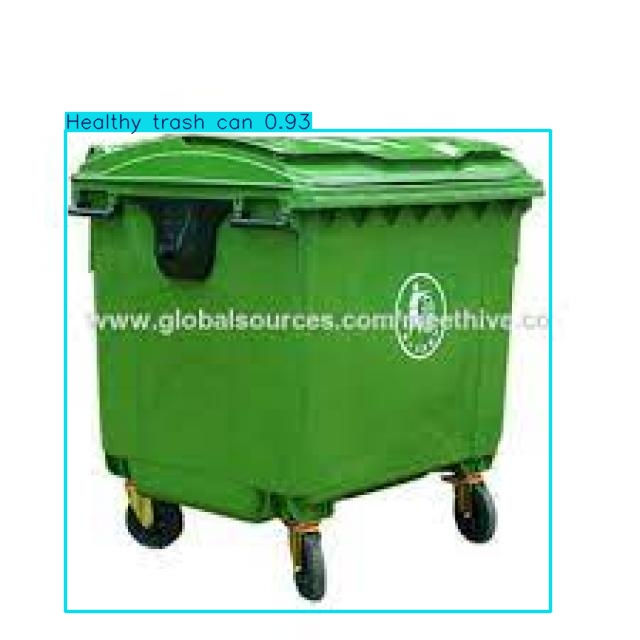

In [24]:
from IPython.display import display, Image

prediction_dir = (
    PROJECT_DIR /
    "prediction" /
    "sample"
)

predicted_images = list(
    prediction_dir.glob("*")
)

if predicted_images:

    display(
        Image(
            filename=str(
                predicted_images[0]
            )
        )
    )

In [80]:
# ============================================================
# PROFESSIONAL ALERT BAR
# ============================================================

import cv2
from datetime import datetime

CLASS_COLORS = {

    0:(255,0,255),      # Broken
    1:(0,255,0),        # Healthy
    2:(0,255,0),        # Closed
    3:(0,255,255),      # Open
    4:(0,0,255)         # Overflow

}


def draw_alert_banner(
        frame,
        detected_classes,
        overflow_tracks,
        fps,
        frame_number
):

    h, w = frame.shape[:2]

    banner_height = 75

    # ---------------------------------------
    # Decide banner colour
    # ---------------------------------------

    if 4 in detected_classes:

        banner_color = (0,0,255)

        title = "CRITICAL ALERT"

        message = "TRASH OVERFLOW DETECTED • IMMEDIATE CLEANING REQUIRED"

    elif 0 in detected_classes or 3 in detected_classes:

        banner_color = (0,215,255)

        title = "WARNING"

        message = "DAMAGED / OPEN TRASH BIN DETECTED"

    else:

        banner_color = (0,170,0)

        title = "NORMAL"

        message = "ALL TRASH BINS ARE OPERATING NORMALLY"

    # ---------------------------------------
    # Banner
    # ---------------------------------------

    overlay = frame.copy()

    cv2.rectangle(

        overlay,

        (0,h-banner_height),

        (w,h),

        banner_color,

        -1

    )

    frame = cv2.addWeighted(
        overlay,
        0.92,
        frame,
        0.08,
        0
    )

    # ---------------------------------------
    # Left text
    # ---------------------------------------

    cv2.putText(

        frame,

        title,

        (25,h-38),

        cv2.FONT_HERSHEY_DUPLEX,

        0.95,

        (255,255,255),

        2,

        cv2.LINE_AA

    )

    cv2.putText(

        frame,

        message,

        (25,h-12),

        cv2.FONT_HERSHEY_SIMPLEX,

        0.60,

        (255,255,255),

        2,

        cv2.LINE_AA

    )

    # ---------------------------------------
    # Right Information
    # ---------------------------------------

    current_time = frame_number/fps

    info = f"Overflow:{len(overflow_tracks)}   Time:{current_time:0.1f}s"

    size = cv2.getTextSize(

        info,

        cv2.FONT_HERSHEY_SIMPLEX,

        0.55,

        2

    )[0]

    cv2.putText(

        frame,

        info,

        (w-size[0]-20,h-25),

        cv2.FONT_HERSHEY_SIMPLEX,

        0.55,

        (255,255,255),

        2,

        cv2.LINE_AA

    )

    return frame

In [81]:
# ============================================================
# PROFESSIONAL SURVEILLANCE ALERT BAR
# ============================================================

import cv2
import numpy as np
from datetime import datetime

def draw_alert_banner(
    frame,
    detected_classes,
    overflow_tracks,
    fps,
    frame_number
):

    h, w = frame.shape[:2]

    banner_height = 90

    # -------------------------------------
    # Determine system state
    # -------------------------------------

    if 4 in detected_classes:

        banner = (0,0,255)

        state = "CRITICAL ALERT"

        message = "TRASH OVERFLOW DETECTED"

        action = "ACTION : DISPATCH CLEANING TEAM"

    elif 0 in detected_classes or 3 in detected_classes:

        banner = (0,215,255)

        state = "WARNING"

        message = "DAMAGED / OPEN TRASH BIN"

        action = "ACTION : INSPECTION REQUIRED"

    else:

        banner = (0,170,0)

        state = "NORMAL"

        message = "ALL TRASH BINS OPERATING NORMALLY"

        action = "SYSTEM MONITORING"

    # -------------------------------------
    # Dark transparent background
    # -------------------------------------

    overlay = frame.copy()

    cv2.rectangle(
        overlay,
        (0,h-banner_height),
        (w,h),
        (20,20,20),
        -1
    )

    frame = cv2.addWeighted(
        overlay,
        0.65,
        frame,
        0.35,
        0
    )

    # -------------------------------------
    # Left coloured strip
    # -------------------------------------

    cv2.rectangle(
        frame,
        (0,h-banner_height),
        (18,h),
        banner,
        -1
    )

    # -------------------------------------
    # Banner title
    # -------------------------------------

    cv2.putText(

        frame,

        state,

        (35,h-55),

        cv2.FONT_HERSHEY_DUPLEX,

        0.95,

        banner,

        2,

        cv2.LINE_AA

    )

    # -------------------------------------
    # Main message
    # -------------------------------------

    cv2.putText(

        frame,

        message,

        (35,h-28),

        cv2.FONT_HERSHEY_SIMPLEX,

        0.62,

        (255,255,255),

        2,

        cv2.LINE_AA

    )

    # -------------------------------------
    # Action line
    # -------------------------------------

    cv2.putText(

        frame,

        action,

        (35,h-8),

        cv2.FONT_HERSHEY_SIMPLEX,

        0.50,

        (230,230,230),

        1,

        cv2.LINE_AA

    )

    # -------------------------------------
    # Right side details
    # -------------------------------------

    current_time = frame_number/fps

    now = datetime.now().strftime("%H:%M:%S")

    info = [

        f"Camera : CAM-01",

        f"Overflow : {len(overflow_tracks)}",

        f"Video : {current_time:.1f}s",

        now

    ]

    y = h-58

    for item in info:

        size = cv2.getTextSize(
            item,
            cv2.FONT_HERSHEY_SIMPLEX,
            0.50,
            1
        )[0]

        cv2.putText(

            frame,

            item,

            (w-size[0]-20,y),

            cv2.FONT_HERSHEY_SIMPLEX,

            0.50,

            (255,255,255),

            1,

            cv2.LINE_AA

        )

        y += 18

    return frame

In [82]:
FINAL_OUTPUT = (
    PROJECT_DIR /
    "final_outputs"
)

FINAL_VIDEO_DIR = (
    FINAL_OUTPUT /
    "videos"
)

FINAL_SNAPSHOT_DIR = (
    FINAL_OUTPUT /
    "snapshots"
)

FINAL_REPORT_DIR = (
    FINAL_OUTPUT /
    "reports"
)

for folder in [
    FINAL_VIDEO_DIR,
    FINAL_SNAPSHOT_DIR,
    FINAL_REPORT_DIR
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print(
    "Output directories ready."
)

Output directories ready.


In [95]:
def process_video(
    video_path,
    confidence=0.40,
    required_overflow_frames=10
):

    video_path = Path(video_path)

    if not video_path.exists():
        raise FileNotFoundError("Uploaded video not found.")

    # ----------------------------------------------------
    # Create unique output folder
    # ----------------------------------------------------

    run_id = uuid.uuid4().hex[:8]

    run_dir = FINAL_OUTPUT / f"run_{run_id}"
    run_dir.mkdir(parents=True, exist_ok=True)

    temp_video = run_dir / "annotated_temp.avi"
    final_video = run_dir / "annotated_output.mp4"

    snapshot_dir = run_dir / "snapshots"
    snapshot_dir.mkdir(parents=True, exist_ok=True)

    csv_path = run_dir / "overflow_events.csv"

    # ----------------------------------------------------
    # Open Video
    # ----------------------------------------------------

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise ValueError("OpenCV could not open this video.")

    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps <= 0:
        fps = 25.0

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if width <= 0 or height <= 0:
        cap.release()
        raise ValueError("Invalid video dimensions.")

    # ----------------------------------------------------
    # Output Video Writer
    # ----------------------------------------------------

    fourcc = cv2.VideoWriter_fourcc(*"MJPG")

    writer = cv2.VideoWriter(
        str(temp_video),
        fourcc,
        fps,
        (width, height)
    )

    if not writer.isOpened():
        cap.release()
        raise RuntimeError("Could not create output video.")

    # ----------------------------------------------------
    # Tracking Variables
    # ----------------------------------------------------

    overflow_frames = defaultdict(int)

    alerted_tracks = set()

    inactive_tracks = defaultdict(int)

    event_records = []

    frame_number = 0

    event_id = 0

    # ----------------------------------------------------
    # Main Loop
    # ----------------------------------------------------

    while True:

        success, frame = cap.read()

        if not success:
            break

        frame_number += 1

        # Used for blinking REC and overflow box
        blink = ((frame_number // 15) % 2 == 0)

        # Every frame starts fresh
        detected_classes = set()

        current_overflow_tracks = set()

        # ------------------------------------------------
        # YOLOv8 + ByteTrack
        # ------------------------------------------------

        results = trained_model.track(

            frame,

            persist=True,

            tracker="bytetrack.yaml",

            conf=confidence,

            device=DEVICE,

            verbose=False

        )

        result = results[0]

        annotated = frame.copy()

        # ------------------------------------------------
        # Process detections
        # ------------------------------------------------

        if result.boxes is not None:

            boxes = result.boxes

            for i in range(len(boxes)):

                class_id = int(boxes.cls[i].item())

                detected_classes.add(class_id)

                class_name = trained_model.names[class_id]

                score = float(boxes.conf[i].item())

                if score < confidence:
                    continue

                x1, y1, x2, y2 = map(
                    int,
                    boxes.xyxy[i].cpu().numpy()
                )

                track_id = None

                if boxes.id is not None:
                    track_id = int(boxes.id[i].item())

                # ------------------------------------------
                # Overflow Logic
                # ------------------------------------------

                is_overflow = (class_id == 4)

                if is_overflow and track_id is not None:

                    current_overflow_tracks.add(track_id)

                    overflow_frames[track_id] += 1

                elif track_id is not None:

                    overflow_frames[track_id] = max(
                        0,
                        overflow_frames[track_id] - 1
                    )

                # ------------------------------------------
                # Bounding box colour selection
                # ------------------------------------------

                if is_overflow:

                    if blink:
                        box_color = (0, 0, 255)
                    else:
                        box_color = (40, 40, 255)

                    label = (
                        f"OVERFLOW | "
                        f"ID:{track_id} | "
                        f"{score:.2f}"
                    )

                elif class_id == 3:

                    box_color = (0, 215, 255)

                    label = (
                        f"OPEN BIN | "
                        f"ID:{track_id} | "
                        f"{score:.2f}"
                    )

                elif class_id == 0:

                    box_color = (255, 0, 255)

                    label = (
                        f"BROKEN BIN | "
                        f"ID:{track_id} | "
                        f"{score:.2f}"
                    )

                else:

                    box_color = (0, 255, 0)

                    label = (
                        f"{class_name} | "
                        f"ID:{track_id} | "
                        f"{score:.2f}"
                    )

                cv2.rectangle(
                    annotated,
                    (x1, y1),
                    (x2, y2),
                    box_color,
                    3
                )

                cv2.putText(
                    annotated,
                    label,
                    (
                        x1,
                        max(25, y1 - 8)
                    ),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.55,
                    box_color,
                    2,
                    cv2.LINE_AA
                )

                # ==========================================================
                # CONFIRMED OVERFLOW EVENT
                # ==========================================================

                if (
                    is_overflow
                    and track_id is not None
                    and overflow_frames[track_id] >= required_overflow_frames
                    and track_id not in alerted_tracks
                ):

                    event_id += 1

                    timestamp = datetime.now().strftime(
                        "%Y-%m-%d %H:%M:%S"
                    )

                    video_seconds = frame_number / fps

                    snapshot_path = (
                        snapshot_dir /
                        f"event_{event_id}_frame_{frame_number}.jpg"
                    )

                    cv2.imwrite(
                        str(snapshot_path),
                        annotated
                    )

                    event_records.append({

                        "event_id": event_id,

                        "timestamp": timestamp,

                        "frame_number": frame_number,

                        "video_time_seconds": round(
                            video_seconds,
                            2
                        ),

                        "track_id": track_id,

                        "class": class_name,

                        "confidence": round(
                            score,
                            4
                        ),

                        "event": "TRASH OVERFLOW",

                        "snapshot": str(snapshot_path)

                    })

                    alerted_tracks.add(track_id)

        # ==========================================================
        # TOP HEADER
        # ==========================================================

        status_height = 75

        cv2.rectangle(
            annotated,
            (0, 0),
            (width, status_height),
            (25, 25, 25),
            -1
        )

        # ----------------------------------------------------------
        # Blinking REC Indicator
        # ----------------------------------------------------------

        if blink:

            cv2.circle(
                annotated,
                (width - 45, 28),
                8,
                (0, 0, 255),
                -1
            )

        cv2.putText(
            annotated,
            "REC",
            (width - 82, 34),
            cv2.FONT_HERSHEY_DUPLEX,
            0.60,
            (255, 255, 255),
            2
        )

        # ----------------------------------------------------------
        # Camera Name
        # ----------------------------------------------------------

        cv2.putText(
            annotated,
            "SMART TRASH CAN MONITOR",
            (20, 32),
            cv2.FONT_HERSHEY_DUPLEX,
            0.72,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )

        # ----------------------------------------------------------
        # Status Text
        # ----------------------------------------------------------

        if len(current_overflow_tracks) > 0:

            status_text = "STATUS : OVERFLOW DETECTED"

            status_color = (0, 0, 255)

        else:

            status_text = "STATUS : MONITORING"

            status_color = (0, 220, 0)

        cv2.putText(
            annotated,
            status_text,
            (20, 63),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.60,
            status_color,
            2,
            cv2.LINE_AA
        )

        # ----------------------------------------------------------
        # Event Counter
        # ----------------------------------------------------------

        cv2.putText(
            annotated,
            f"Events : {event_id}",
            (width - 180, 62),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.60,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )

        # ==========================================================
        # PROFESSIONAL ALERT BANNER
        # ==========================================================

        annotated = draw_alert_banner(

            frame=annotated,

            detected_classes=detected_classes,

            overflow_tracks=current_overflow_tracks,

            fps=fps,

            frame_number=frame_number

        )

        # ==========================================================
        # WRITE FRAME
        # ==========================================================

        writer.write(annotated)

        # ==========================================================
        # PROGRESS
        # ==========================================================

        if frame_number % 100 == 0:

            if total_frames > 0:

                progress = (
                    frame_number /
                    total_frames
                ) * 100

                print(
                    f"Processing : {progress:.1f}%"
                )

    # ==========================================================
    # RELEASE RESOURCES
    # ==========================================================

    cap.release()
    writer.release()

    # ==========================================================
    # SAVE CSV REPORT
    # ==========================================================

    report_df = pd.DataFrame(event_records)

    if report_df.empty:

        report_df = pd.DataFrame(
            columns=[
                "event_id",
                "timestamp",
                "frame_number",
                "video_time_seconds",
                "track_id",
                "class",
                "confidence",
                "event",
                "snapshot"
            ]
        )

    report_df.to_csv(
        csv_path,
        index=False
    )

    # ==========================================================
    # CONVERT AVI → MP4
    # ==========================================================

    ffmpeg_available = shutil.which("ffmpeg") is not None

    if ffmpeg_available:

        command = [

            "ffmpeg",
            "-y",

            "-i",
            str(temp_video),

            "-c:v",
            "libx264",

            "-pix_fmt",
            "yuv420p",

            "-movflags",
            "+faststart",

            str(final_video)

        ]

        conversion = subprocess.run(

            command,

            stdout=subprocess.PIPE,

            stderr=subprocess.PIPE,

            text=True

        )

        if conversion.returncode != 0:

            print("⚠ FFmpeg conversion failed.")
            print(conversion.stderr)

            shutil.copy2(
                temp_video,
                final_video
            )

    else:

        print("⚠ FFmpeg not found. Copying AVI.")

        shutil.copy2(
            temp_video,
            final_video
        )

    # ==========================================================
    # SUMMARY
    # ==========================================================

    summary = {

        "total_frames":
        frame_number,

        "fps":
        round(
            fps,
            2
        ),

        "duration_seconds":
        round(
            frame_number / fps,
            2
        ),

        "overflow_events":
        event_id,

        "output_video":
        str(final_video),

        "csv_report":
        str(csv_path),

        "snapshot_directory":
        str(snapshot_dir)

    }

    print("\n========================================")

    print("Processing Complete")

    print(f"Frames Processed : {frame_number}")

    print(f"Overflow Events  : {event_id}")

    print(f"Output Video     : {final_video}")

    print(f"CSV Report       : {csv_path}")

    print("========================================\n")

    return (

        str(final_video),

        report_df,

        summary

    )

In [96]:
TEST_VIDEO = "/kaggle/input/datasets/prachiii33/videos/istockphoto-1335925810-640_adpp_is.mp4"

In [97]:
output_video, event_df, summary = process_video(
    video_path=TEST_VIDEO,
    confidence=0.40,
    required_overflow_frames=10
)

print(
    json.dumps(
        summary,
        indent=4
    )
)

display(event_df)

Processing : 35.2%
Processing : 70.4%

Processing Complete
Frames Processed : 284
Overflow Events  : 3
Output Video     : /kaggle/working/trash_can_overflow_project/final_outputs/run_8da41888/annotated_output.mp4
CSV Report       : /kaggle/working/trash_can_overflow_project/final_outputs/run_8da41888/overflow_events.csv

{
    "total_frames": 284,
    "fps": 25.0,
    "duration_seconds": 11.36,
    "overflow_events": 3,
    "output_video": "/kaggle/working/trash_can_overflow_project/final_outputs/run_8da41888/annotated_output.mp4",
    "csv_report": "/kaggle/working/trash_can_overflow_project/final_outputs/run_8da41888/overflow_events.csv",
    "snapshot_directory": "/kaggle/working/trash_can_overflow_project/final_outputs/run_8da41888/snapshots"
}


,event_id,timestamp,frame_number,video_time_seconds,track_id,class,confidence,event,snapshot
0,1,2026-08-06 10:33:17,11,0.44,49,Trash over flow,0.7510,TRASH OVERFLOW,/kaggle/working/trash_can_overflow_project/fin...
1,2,2026-08-06 10:33:18,46,1.84,52,Trash over flow,0.4398,TRASH OVERFLOW,/kaggle/working/trash_can_overflow_project/fin...
2,3,2026-08-06 10:33:20,168,6.72,54,Trash over flow,0.4686,TRASH OVERFLOW,/kaggle/working/trash_can_overflow_project/fin...


In [98]:
from IPython.display import Video, display

display(
    Video(
        output_video,
        embed=True
    )
)

In [99]:
import gradio as gr

In [100]:
def run_application(uploaded_video):

    if uploaded_video is None:

        raise gr.Error(
            "Please upload a CCTV or surveillance video."
        )

    try:

        video_path, event_df, summary = (
            process_video(
                video_path=uploaded_video,
                confidence=0.40,
                required_overflow_frames=10
            )
        )

        snapshot_paths = []

        if event_df is not None:

            for snapshot in (
                event_df["snapshot"]
                .tolist()
                if "snapshot"
                in event_df.columns
                else []
            ):

                if Path(snapshot).exists():

                    snapshot_paths.append(
                        (
                            snapshot,
                            f"Overflow Event"
                        )
                    )

        if summary["overflow_events"] > 0:

            status = (
                "🚨 OVERFLOW DETECTED\n\n"
                f"Confirmed events: "
                f"{summary['overflow_events']}\n"
                f"Video duration: "
                f"{summary['duration_seconds']} seconds"
            )

        else:

            status = (
                "✅ NO OVERFLOW EVENTS CONFIRMED\n\n"
                f"Video duration: "
                f"{summary['duration_seconds']} seconds"
            )

        return (
            video_path,
            event_df,
            snapshot_paths,
            summary["csv_report"],
            status
        )

    except Exception as e:

        raise gr.Error(
            f"Processing failed:\n{str(e)}"
        )

In [101]:
import gradio as gr

with gr.Blocks() as demo:

    gr.Markdown(
        """
        # 🗑️ Smart Trash Can Monitoring System

        ### AI-Based Trash Overflow Detection

        Upload a CCTV or surveillance video.
        The system detects trash cans, identifies
        overflowing bins, tracks them across frames,
        and generates evidence-backed overflow events.
        """
    )

    gr.Markdown(
        """
        **Detection Classes**

        🟢 Healthy trash can  
        🟢 Trash can closed  
        🟠 Trash can open  
        🟣 Broken trash can  
        🔴 Trash over flow
        """
    )

    # --------------------------------------------------
    # VIDEO INPUT
    # --------------------------------------------------

    video_input = gr.Video(
        label="Upload CCTV / Surveillance Video",
        sources=["upload"]
    )

    # --------------------------------------------------
    # PROCESS BUTTON
    # --------------------------------------------------

    process_button = gr.Button(
        "🚨 ANALYZE VIDEO",
        variant="primary"
    )

    # --------------------------------------------------
    # STATUS
    # --------------------------------------------------

    status_output = gr.Textbox(
        label="Expected Output / System Status",
        lines=4
    )

    # --------------------------------------------------
    # OUTPUTS
    # --------------------------------------------------

    with gr.Row():

        output_video = gr.Video(
            label="Annotated Output Video"
        )

        event_report = gr.File(
            label="Download Event Report"
        )

    event_table = gr.Dataframe(
        label="Confirmed Overflow Events",
        interactive=False
    )

    evidence_gallery = gr.Gallery(
        label="Overflow Evidence",
        columns=3,
        rows=2
    )

    # --------------------------------------------------
    # BUTTON ACTION
    # --------------------------------------------------

    process_button.click(
        fn=run_application,
        inputs=video_input,
        outputs=[
            output_video,
            event_table,
            evidence_gallery,
            event_report,
            status_output
        ]
    )


# ------------------------------------------------------
# LAUNCH
# ------------------------------------------------------

demo.launch(
    share=True,
    debug=True
)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://ff4294b9f617ae9205.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

Processing : 13.2%
Processing : 26.5%
Processing : 39.7%
Processing : 52.9%
Processing : 66.1%
Processing : 79.4%
Processing : 92.6%

Processing Complete
Frames Processed : 756
Overflow Events  : 3
Output Video     : /kaggle/working/trash_can_overflow_project/final_outputs/run_181d8a25/annotated_output.mp4
CSV Report       : /kaggle/working/trash_can_overflow_project/final_outputs/run_181d8a25/overflow_events.csv



ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Processing : 47.8%
Processing : 95.7%

Processing Complete
Frames Processed : 209
Overflow Events  : 3
Output Video     : /kaggle/working/trash_can_overflow_project/final_outputs/run_0aecbafa/annotated_output.mp4
CSV Report       : /kaggle/working/trash_can_overflow_project/final_outputs/run_0aecbafa/overflow_events.csv



ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Processing : 22.2%
Processing : 44.4%
Processing : 66.7%
Processing : 88.9%

Processing Complete
Frames Processed : 450
Overflow Events  : 1
Output Video     : /kaggle/working/trash_can_overflow_project/final_outputs/run_eeee0a4a/annotated_output.mp4
CSV Report       : /kaggle/working/trash_can_overflow_project/final_outputs/run_eeee0a4a/overflow_events.csv



ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Processing : 15.8%
Processing : 31.6%
Processing : 47.5%
Processing : 63.3%
Processing : 79.1%
Processing : 94.9%

Processing Complete
Frames Processed : 632
Overflow Events  : 5
Output Video     : /kaggle/working/trash_can_overflow_project/final_outputs/run_417344ee/annotated_output.mp4
CSV Report       : /kaggle/working/trash_can_overflow_project/final_outputs/run_417344ee/overflow_events.csv

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://ff4294b9f617ae9205.gradio.live
